# Assignment 1 — Cointegration & Pairs Trading

**Course:** Financial Engineering · Module 1
**Topic:** Empirical introduction to cointegration and pairs trading
**Data source:** Yahoo Finance via `yfinance`
**Frequency:** Daily close prices

---

## 1. Introduction

Under the Efficient Markets Hypothesis (Fama), individual asset prices behave approximately as random walks and are therefore non-stationary. However, *linear combinations* of non-stationary series can themselves be stationary — this is the property known as **cointegration** (Engle & Granger, 1987). When two assets are cointegrated, the spread between them is mean-reverting, and that mean reversion can be exploited via **pairs trading**: short the spread when it is rich, long the spread when it is cheap, and close out when it returns to equilibrium.

This notebook implements an empirical, end-to-end pairs-trading pipeline. Following the assignment specification, we select **two pairs from two distinct universes**:

| | Universe | Selected pair |
|---|---|---|
| **Pair 1** | Equities (single-name stocks) | Visa (V) and Mastercard (MA) |
| **Pair 2** | ETFs and currencies | SPDR S&P 500 (SPY) and Vanguard S&P 500 (VOO) |

Each pair is treated as a self-contained section: universe definition → correlation screen → cointegration testing → cointegrating regression → spread / z-score → backtest → interpretation.

> **Note on workflow.** Correlation is used only as a *screen*. The actual statistical evidence for a tradeable relationship comes from cointegration tests on price levels, not from correlation.

## 2. Setup

Install dependencies if needed:

```bash
pip install yfinance seaborn statsmodels matplotlib pandas numpy
```


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.stattools import coint, adfuller

# Plot defaults
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_style('whitegrid')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

### 2.1 Universes and date range

We screen two separate universes so that each pair is sourced from the asset class specified by the assignment.

**Stock universe (Pair 1 source).** Same-industry US equity candidates grouped by sector — airlines, money-center banks, semiconductors, beverages, card networks, integrated oil & gas. These are classical pairs-trade candidates because firms in the same sub-industry share fundamental drivers (same demand cycle, same input costs, same regulatory regime).

**ETF / FX universe (Pair 2 source).** Index-tracking ETFs and major-currency pairs. The ETFs include two S&P 500 proxies (SPY, VOO), two gold-bullion wrappers (GLD, IAU), large-cap China (FXI, MCHI), leveraged Nasdaq-100 (QLD, TQQQ), Japan equity and the yen (EWJ, FXY). The currency pairs follow Yahoo Finance's required `=X` suffix.

**Date range.** 2014-01-01 to 2025-03-25 — approximately 11 years, covering a full business cycle including COVID-19 and the 2022 rate-hike regime.

In [2]:
# ── Universe definitions ────────────────────────────────────────────────────
STOCK_LIST = [
    'DAL', 'UAL',          # US airlines
    'JPM', 'BAC',          # US money-center banks
    'NVDA', 'AMD',         # GPUs / semiconductors
    'KO',  'PEP',          # Beverages
    'V',   'MA',           # Card networks
    'XOM', 'CVX',          # Integrated oil & gas
]

ETF_FX_LIST = [
    'SPY', 'VOO',          # S&P 500 proxies
    'GLD', 'IAU',          # Physical-gold ETFs
    'FXI', 'MCHI',         # Large-cap China
    'QLD', 'TQQQ',         # Leveraged Nasdaq-100
    'EWJ', 'FXY',          # Japan equity & JPY
    'EURUSD=X', 'GBPUSD=X',  # FX (Yahoo requires =X suffix)
]

START_DATE = '2014-01-01'
END_DATE   = '2025-03-25'

## 3. Data download

`yf.download(..., auto_adjust=True)` returns prices already adjusted for splits and dividends, so the resulting `Close` column is the total-return-adjusted close. With multiple tickers, the result has a `MultiIndex` on columns (`(field, ticker)`); we extract the `Close` cross-section.

We download both universes in a single call (faster, single set of date alignments) and then split into two DataFrames for downstream analysis.

In [3]:
# ── Data download (provided base script) ────────────────────────────────────
def download_stock_data(symbols: list[str], start_date: str, end_date: str) -> pd.DataFrame:
    """
    Download daily adjusted close prices for a list of ticker symbols.

    Parameters
    ----------
    symbols    : list of ticker strings
    start_date : 'YYYY-MM-DD' start of date range
    end_date   : 'YYYY-MM-DD' end of date range

    Returns
    -------
    pd.DataFrame with dates as index and tickers as columns
    """
    raw = yf.download(symbols, start=start_date, end=end_date, auto_adjust=True, progress=False)

    # yfinance returns MultiIndex columns when >1 ticker; flatten to Close only
    if isinstance(raw.columns, pd.MultiIndex):
        data = raw['Close']
    else:
        data = raw[['Close']]
        data.columns = symbols

    data.dropna(how='all', inplace=True)
    return data


print('Downloading price data …')
all_prices    = download_stock_data(STOCK_LIST + ETF_FX_LIST, START_DATE, END_DATE)
stock_prices  = all_prices[[t for t in STOCK_LIST  if t in all_prices.columns]]
etf_fx_prices = all_prices[[t for t in ETF_FX_LIST if t in all_prices.columns]]

print(f'  Stocks   : {len(stock_prices):,} days × {stock_prices.shape[1]} tickers')
print(f'  ETF / FX : {len(etf_fx_prices):,} days × {etf_fx_prices.shape[1]} tickers')
print(f'  Range    : {all_prices.index.min().date()} → {all_prices.index.max().date()}')

  Stocks   : 2,928 days × 12 tickers
  ETF / FX : 2,928 days × 12 tickers
  Range    : 2014-01-01 → 2025-03-24


## 4. Pairs-trading framework

This section defines the reusable functions that will be applied identically to both pairs. The first four are taken from the provided base script (`Assign1_2026_v1.txt`), with only minor cosmetic additions (`figsize` / `title_suffix` parameters so the same function can be reused for both universes); the rest are extensions we built on top to cover steps 5–6 of the workflow (strategy design and backtesting).

| Function | Origin | Purpose |
|---|---|---|
| `download_stock_data`            | Provided | Daily adjusted close prices from Yahoo Finance |
| `generate_correlation_heatmap`   | Provided | Pearson correlation on price levels (screening step 1) |
| `find_cointegrated_pairs`        | Provided | Pairwise Engle–Granger cointegration tests (screening step 2) |
| `plot_cointegration_heatmap`     | Provided | Visualise significant cointegration p-values |
| `coint_results_table`            | New (display helper) | Reshape the four matrices from `find_cointegrated_pairs` into a ranked DataFrame |
| `build_spread`                   | New | OLS hedge ratio + ADF on residuals + spread series |
| `generate_signals`               | New | Z-score state machine producing positions |
| `backtest_pair`                  | New | Strategy P&L and equity / drawdown |
| `plot_pair_diagnostics`, `plot_rolling_sharpe`, `print_metrics` | New | Standard diagnostic outputs |

### 4.1 Strategy rules (applied identically to both pairs)

**Spread.** $S_t = P_{1,t} - \beta P_{2,t}$ where $\beta$ comes from the Engle–Granger first-stage OLS.

**Z-score.** Full-sample standardization $Z_t = (S_t - \bar{S}) / \sigma_S$. (We acknowledge the look-ahead bias and discuss the walk-forward fix in §7.)

**Entry/exit.**

| Condition | Action |
|---|---|
| $Z_t > +2$  | Enter **short spread** (sell $P_1$, buy $\beta$ units of $P_2$) |
| $Z_t < -2$  | Enter **long spread** (buy $P_1$, sell $\beta$ units of $P_2$) |
| $\lvert Z_t \rvert < 0.5$ | Exit (close any open position) |
| otherwise | Hold previous position |

**P&L.** Position is shifted by one bar to avoid look-ahead, so $r^{\text{strat}}_t = \text{pos}_{t-1} \cdot (r^{(1)}_t - \beta \cdot r^{(2)}_t)$. The backtest is gross of transaction costs; costs are discussed as a limitation in §7.3.

In [4]:
# ── Correlation heatmap (provided base script — unchanged signature) ────────
def generate_correlation_heatmap(data: pd.DataFrame, figsize=(10, 8), title_suffix: str = '') -> None:
    """
    Plot a Pearson correlation heatmap of raw close prices (price levels).

    NOTE: Correlating non-stationary price levels produces artificially high
    coefficients driven by shared upward trends rather than genuine co-movement.
    This is intentional here to illustrate spurious correlation — pairs that
    look tightly linked in price space may have no meaningful economic relationship.

    Parameters
    ----------
    data         : DataFrame of close prices (dates × tickers)
    figsize      : matplotlib figure size  (added so we can use smaller plots
                   for each universe; original default was (14, 10))
    title_suffix : optional string appended to the plot title (added)
    """
    matrix = data.corr().round(2)

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        matrix,
        cmap='RdYlGn_r',
        annot=True,
        fmt='.2f',
        linewidths=0.5,
        vmin=-1, vmax=1,
        ax=ax,
    )
    ax.set_title(
        f'Correlation Heatmap of Price Levels{title_suffix}\n'
        '(inflated by shared trends — illustrates spurious correlation)',
        fontsize=13, pad=12,
    )
    plt.tight_layout()
    plt.show()


# ── Cointegration analysis (provided base script — unchanged signature) ─────
def find_cointegrated_pairs(
    data: pd.DataFrame,
    symbols: list[str],
    pvalue_threshold: float = 0.10,
) -> tuple[np.ndarray, np.ndarray, list[tuple], np.ndarray]:
    """
    Perform pairwise Engle-Granger cointegration tests.

    Parameters
    ----------
    data              : DataFrame of close prices (dates × tickers)
    symbols           : ordered list of ticker strings
    pvalue_threshold  : significance level for flagging pairs (default 0.10)

    Returns
    -------
    score_matrix  : (n×n) array of ADF test statistics
    pvalue_matrix : (n×n) array of p-values  (lower-triangle unused / ones)
    pairs         : list of (sym_i, sym_j) tuples that pass the threshold
    beta_matrix   : (n×n) array of OLS hedge ratios
    """
    n             = len(symbols)
    score_matrix  = np.zeros((n, n))
    pvalue_matrix = np.ones((n, n))
    beta_matrix   = np.zeros((n, n))
    pairs: list[tuple] = []

    for i in range(n):
        for j in range(i + 1, n):
            s1 = data[symbols[i]].dropna()
            s2 = data[symbols[j]].dropna()

            # Align on common dates
            s1, s2 = s1.align(s2, join='inner')

            score, pvalue, _ = coint(s1, s2)
            model = sm.OLS(s1, sm.add_constant(s2)).fit()

            score_matrix[i, j]  = score
            pvalue_matrix[i, j] = pvalue
            beta_matrix[i, j]   = model.params.iloc[1]

            if pvalue < pvalue_threshold:
                pairs.append((symbols[i], symbols[j]))

    return score_matrix, pvalue_matrix, pairs, beta_matrix


# ── Cointegration heatmap (provided base script — unchanged signature) ──────
def plot_cointegration_heatmap(
    pvalue_matrix: np.ndarray,
    symbols: list[str],
    pvalue_threshold: float = 0.10,
    figsize=(9, 8),
    title_suffix: str = '',
) -> None:
    """
    Plot a heatmap of cointegration p-values, masking non-significant pairs.

    Parameters
    ----------
    pvalue_matrix     : (n×n) array from find_cointegrated_pairs
    symbols           : ordered list of ticker strings
    pvalue_threshold  : mask cells at or above this value (default 0.10)
    figsize           : matplotlib figure size (added; original default was (10, 9))
    title_suffix      : appended to the plot title (added)
    """
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        pvalue_matrix,
        xticklabels=symbols,
        yticklabels=symbols,
        cmap='RdYlGn_r',
        mask=(pvalue_matrix >= pvalue_threshold),
        annot=True,
        fmt='.3f',
        linewidths=0.5,
        cbar_kws={'label': 'p-value'},
        vmin=0, vmax=pvalue_threshold,
        ax=ax,
    )
    ax.set_title(
        f'Cointegration p-values (threshold < {pvalue_threshold}){title_suffix}',
        fontsize=14, pad=12,
    )
    plt.tight_layout()
    plt.show()


# ── Display helper (extension) ──────────────────────────────────────────────
def coint_results_table(
    scores: np.ndarray,
    pvalues: np.ndarray,
    betas: np.ndarray,
    symbols: list[str],
) -> pd.DataFrame:
    """Convert the upper-triangle matrices from find_cointegrated_pairs() into a
    long-format DataFrame sorted by p-value. Display-only — does not change the
    provided function's contract."""
    rows = []
    for i in range(len(symbols)):
        for j in range(i + 1, len(symbols)):
            rows.append({
                'asset_1':  symbols[i],
                'asset_2':  symbols[j],
                'adf_stat': scores[i, j],
                'pvalue':   pvalues[i, j],
                'beta':     betas[i, j],
            })
    return pd.DataFrame(rows).sort_values('pvalue').reset_index(drop=True)

In [5]:
# ── Spread construction (cointegrating regression + ADF on residuals) ───────
def build_spread(
    prices: pd.DataFrame,
    ticker_1: str,
    ticker_2: str,
) -> tuple[pd.Series, pd.Series, float, float, dict]:
    """Align two series, estimate alpha/beta by OLS, ADF on residuals."""
    pair = prices[[ticker_1, ticker_2]].dropna()
    s1, s2 = pair[ticker_1], pair[ticker_2]
    model = sm.OLS(s1, sm.add_constant(s2)).fit()
    alpha, beta = model.params.iloc[0], model.params.iloc[1]

    spread = s1 - beta * s2
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(spread.dropna(), autolag='AIC')

    diagnostics = {
        'alpha':     alpha,
        'beta':      beta,
        'r_squared': model.rsquared,
        'adf_stat':  adf_stat,
        'adf_p':     adf_p,
        'adf_crit':  adf_crit,
    }
    return s1, s2, alpha, beta, diagnostics


# ── Signal generation (state machine — explicit loop because rule has memory)
def generate_signals(
    zscore: pd.Series,
    entry: float = 2.0,
    exit_: float = 0.5,
) -> pd.Series:
    """Generate {-1, 0, +1} positions from a z-score with hysteresis."""
    z = zscore.values
    pos = np.zeros(len(z), dtype=np.int8)
    for t in range(1, len(z)):
        prev = pos[t - 1]
        if abs(z[t]) < exit_:
            pos[t] = 0
        elif z[t] < -entry:
            pos[t] = 1
        elif z[t] > entry:
            pos[t] = -1
        else:
            pos[t] = prev
    return pd.Series(pos, index=zscore.index, name='position')


# ── Backtest ────────────────────────────────────────────────────────────────
def backtest_pair(
    s1: pd.Series,
    s2: pd.Series,
    beta: float,
    entry: float = 2.0,
    exit_: float = 0.5,
) -> dict:
    """Run the pairs-trading backtest and return spread / signal / equity / metrics.

    Cost model: gross of transaction costs (assignment treats costs as a
    discussion-level limitation, not a backtest input).
    """
    spread = s1 - beta * s2
    z = (spread - spread.mean()) / spread.std()
    pos = generate_signals(z, entry=entry, exit_=exit_)

    r1 = s1.pct_change()
    r2 = s2.pct_change()
    strat_ret = (pos.shift(1) * (r1 - beta * r2)).fillna(0)

    equity = (1 + strat_ret).cumprod()
    dd = (equity - equity.cummax()) / equity.cummax()

    ann = 252
    mu, sigma = strat_ret.mean(), strat_ret.std()
    sharpe = (mu / sigma) * np.sqrt(ann) if sigma > 0 else np.nan
    n_years = len(strat_ret) / ann
    cagr = equity.iloc[-1] ** (1 / n_years) - 1 if n_years > 0 else np.nan
    n_trades = int((pos.diff().abs() > 0).sum())

    return {
        'spread': spread, 'zscore': z, 'position': pos,
        'strategy_return': strat_ret,
        'equity': equity, 'drawdown': dd,
        'metrics': {
            'total_return': equity.iloc[-1] - 1,
            'cagr':         cagr,
            'sharpe':       sharpe,
            'max_drawdown': dd.min(),
            'n_trades':     n_trades,
        },
    }

In [6]:
# ── Plotting helpers ────────────────────────────────────────────────────────
def plot_pair_diagnostics(
    s1: pd.Series, s2: pd.Series, bt: dict,
    name_1: str, name_2: str, beta: float,
    entry: float = 2.0, exit_: float = 0.5,
) -> None:
    """Four-panel: normalized prices, spread, z-score with signals, equity + drawdown."""
    fig, axes = plt.subplots(4, 1, figsize=(14, 16))

    ax = axes[0]
    (s1 / s1.iloc[0]).plot(ax=ax, label=name_1, linewidth=1.5)
    (s2 / s2.iloc[0]).plot(ax=ax, label=name_2, linewidth=1.5)
    ax.set_title(f'Normalized prices (rebased to 1.0): {name_1} vs {name_2}')
    ax.set_ylabel('Price (rebased)')
    ax.legend()

    ax = axes[1]
    bt['spread'].plot(ax=ax, label='Spread', linewidth=1.2)
    ax.axhline(bt['spread'].mean(), color='red', ls='--', alpha=0.7,
               label=f'Mean = {bt["spread"].mean():.2f}')
    ax.set_title(f'Spread: {name_1} − {beta:.4f} × {name_2}')
    ax.set_ylabel('Spread')
    ax.legend()

    ax = axes[2]
    bt['zscore'].plot(ax=ax, label='Z-score', linewidth=1.0, color='steelblue')
    ax.axhline(+entry, color='red',   ls='--', alpha=0.7, label=f'+{entry} short entry')
    ax.axhline(-entry, color='green', ls='--', alpha=0.7, label=f'−{entry} long entry')
    ax.axhline(+exit_, color='gray',  ls=':',  alpha=0.6)
    ax.axhline(-exit_, color='gray',  ls=':',  alpha=0.6, label=f'±{exit_} exit')
    ax.axhline(0, color='black', alpha=0.5)
    longs  = bt['position'] == 1
    shorts = bt['position'] == -1
    ax.fill_between(bt['zscore'].index, bt['zscore'].min(), bt['zscore'].max(),
                    where=longs, alpha=0.10, color='green', step='post')
    ax.fill_between(bt['zscore'].index, bt['zscore'].min(), bt['zscore'].max(),
                    where=shorts, alpha=0.10, color='red',   step='post')
    ax.set_title('Spread z-score with entry / exit thresholds')
    ax.set_ylabel('Z-score')
    ax.legend(loc='upper right', ncol=2)

    ax = axes[3]
    bt['equity'].plot(ax=ax, label='Strategy equity', linewidth=1.5, color='navy')
    ax.set_title('Strategy equity curve')
    ax.set_ylabel('Equity (start = 1.0)')
    ax.legend(loc='upper left')
    ax2 = ax.twinx()
    ax2.fill_between(bt['drawdown'].index, bt['drawdown'].values, 0,
                     color='red', alpha=0.25, label='Drawdown')
    ax2.set_ylabel('Drawdown', color='red')
    ax2.tick_params(axis='y', colors='red')
    ax2.grid(False)

    plt.tight_layout()
    plt.show()


def plot_rolling_sharpe(strat_return: pd.Series, window: int = 252) -> None:
    """Rolling annualized Sharpe ratio."""
    rs = (strat_return.rolling(window).mean() / strat_return.rolling(window).std()) * np.sqrt(252)
    fig, ax = plt.subplots(figsize=(13, 4))
    rs.plot(ax=ax, color='darkblue', linewidth=1.5)
    ax.axhline(0, color='black', ls='--', alpha=0.7)
    ax.axhline(1, color='green', ls=':',  alpha=0.5, label='Sharpe = 1')
    ax.set_title(f'Rolling {window}-day annualized Sharpe ratio')
    ax.set_ylabel('Sharpe')
    ax.legend()
    plt.tight_layout()
    plt.show()


def print_metrics(metrics: dict, label: str) -> None:
    """Print backtest summary metrics."""
    bar = '─' * max(0, 50 - len(label))
    print(f'─── Backtest results: {label} {bar}')
    print(f'  Total return     : {metrics["total_return"]:>9.2%}')
    print(f'  CAGR             : {metrics["cagr"]:>9.2%}')
    print(f'  Sharpe (ann.)    : {metrics["sharpe"]:>9.2f}')
    print(f'  Maximum drawdown : {metrics["max_drawdown"]:>9.2%}')
    print(f'  Number of trades : {metrics["n_trades"]:>9d}')

## 5. Pair 1 — Equities

This section runs the full screening → selection → backtest pipeline on the **stock universe**.

### 5.1 Screening — correlation

Correlation is the standard first filter for pairs trading: two assets that don't move together are unlikely to have a stable spread. But correlation on **price levels** is well known to be misleading — two unrelated assets that both trend upward over a decade will appear highly correlated. This is *spurious correlation*.

The heatmap below uses price levels and demonstrates this: most equities show correlation > 0.9 simply because they trend upward together over 2014–2025. The takeaway is that correlation is a necessary but not sufficient screen; we need cointegration tests to identify genuine equilibrium relationships.

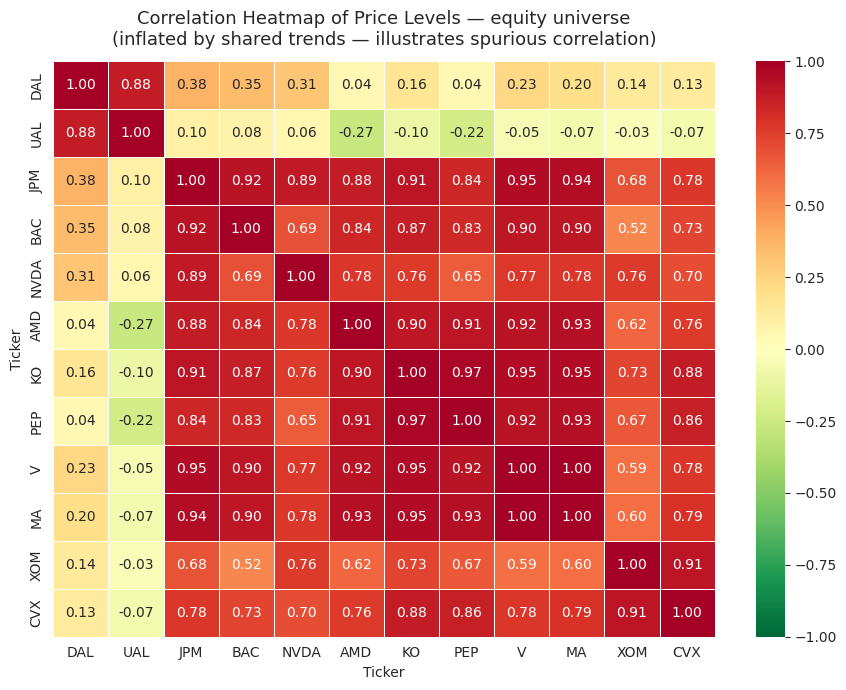

In [7]:
generate_correlation_heatmap(
    stock_prices,
    figsize=(9, 7),
    title_suffix=' — equity universe',
)

### 5.2 Cointegration testing

We apply the **Engle–Granger two-step procedure** to every pair $(i, j)$ with $i < j$ in the stock universe:

1. Estimate the cointegrating regression by OLS:
$$P_{1,t} = \alpha + \beta P_{2,t} + \varepsilon_t$$
2. Test the residuals $\hat{\varepsilon}_t$ for stationarity using an Augmented Dickey–Fuller (ADF) test.

**Hypotheses:**

- $H_0$: $\hat{\varepsilon}_t$ has a unit root → the pair is **not** cointegrated (spread follows a random walk).
- $H_a$: $\hat{\varepsilon}_t$ is stationary → the pair **is** cointegrated.

We reject $H_0$ when the p-value is below our chosen threshold (here 10%).

> **Note on direction.** The OLS hedge ratio depends on which asset is the dependent variable: regressing $P_1$ on $P_2$ gives a different $\beta$ from regressing $P_2$ on $P_1$. We adopt the convention "regress the alphabetically-first ticker on the second" so each upper-triangle pair $(s_i, s_j)$ with $i<j$ defines $\text{spread} = P_i - \beta \cdot P_j$.

In [8]:
stock_scores, stock_pvalues, stock_pairs, stock_betas = find_cointegrated_pairs(
    stock_prices, list(stock_prices.columns), pvalue_threshold=0.10,
)

n_pairs = len(stock_prices.columns) * (len(stock_prices.columns) - 1) // 2
print(f'Tested {n_pairs} stock pairs; {len(stock_pairs)} significant at p<0.10\n')
print('Top 10 candidate stock pairs (lowest p-value):')
stock_coint_table = coint_results_table(
    stock_scores, stock_pvalues, stock_betas, list(stock_prices.columns),
)
stock_coint_table.head(10).style.format({
    'adf_stat': '{:.3f}', 'pvalue': '{:.4f}', 'beta': '{:.4f}',
})

Tested 66 stock pairs; 14 significant at p<0.10

Top 10 candidate stock pairs (lowest p-value):


,asset_1,asset_2,adf_stat,pvalue,beta
0,V,MA,-3.942,0.0087,0.5575
1,DAL,UAL,-3.824,0.0126,0.4304
2,DAL,NVDA,-3.322,0.0518,0.0774
3,DAL,XOM,-3.201,0.0698,0.0556
4,DAL,AMD,-3.192,0.0713,0.0059
5,DAL,PEP,-3.182,0.0729,0.0099
6,BAC,KO,-3.182,0.0730,0.7227
7,DAL,V,-3.179,0.0735,0.0258
8,DAL,MA,-3.177,0.0739,0.0129
9,DAL,KO,-3.175,0.0742,0.1258


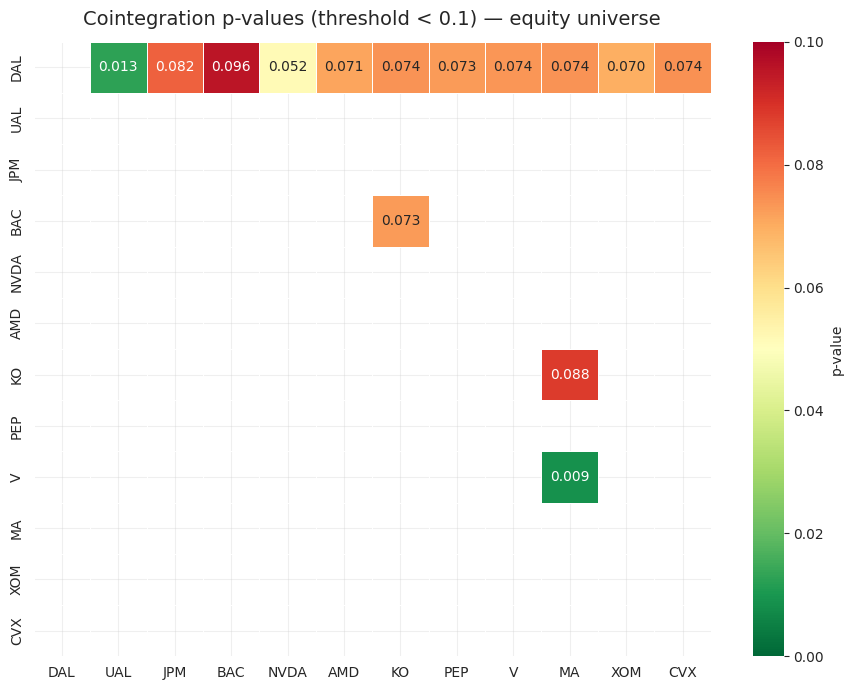

In [9]:
plot_cointegration_heatmap(
    stock_pvalues, list(stock_prices.columns),
    pvalue_threshold=0.10,
    figsize=(9, 7),
    title_suffix=' — equity universe',
)

### 5.3 Pair selection — Visa (V) vs Mastercard (MA)

**Why this pair?**

Two filters drive selection: statistical (the cointegration result) and economic (a coherent reason for the relationship to persist). In our stock universe these align cleanly on V/MA:

- *Statistical:* V/MA has the **lowest p-value** in the universe (p = 0.009 with V as the dependent variable, which is the direction we trade; the reversed-direction regression MA on V gives p = 0.008 — both well below the 5% level, the only stock pair to clear 5%). DAL/UAL is the runner-up at p ≈ 0.013; the remaining ~10 pairs that pass at p<0.10 all cluster between 0.05 and 0.10, and most are cross-sector pairings (DAL/NVDA, BAC/KO, KO/MA, AMD/KO) without a coherent economic driver.
- *Economic:* duopoly economics give us a *reason* for the relationship to revert, which reduces the risk that the cointegration result is a sample artifact rather than a stable structural relationship. Cross-sector pairs that pass the test (e.g. DAL/NVDA) are almost certainly spurious — there is no economic mechanism that would cause an airline and a GPU manufacturer to maintain a long-run equilibrium price ratio.

V/MA is the rare pair where statistical and economic evidence converge.

**Economic motivation.**

Visa and Mastercard form a **duopoly** in global open-loop payment-card networks. Both companies earn fee revenue on essentially the same payment volume (consumer card swipes processed through their proprietary network rails), and both face the same macro drivers:

- **Consumer spending growth** — drives total payment volume.
- **Cross-border travel** — high-margin FX-fee revenue for both.
- **Card vs cash mix shift** — a long secular tailwind that benefits both equally.
- **Regulatory pressure** — interchange-fee caps (e.g. Durbin Amendment, EU IFR) affect both symmetrically.

Their cost structures, growth profiles, valuation multiples, and capital-return policies have tracked closely for over a decade. Idiosyncratic shocks (a contract win, an executive departure, an antitrust action against only one) cause **temporary** divergence, but the duopoly economics pull them back together. This is the canonical pairs-trade textbook example and we expect the spread to be cointegrated.

In [10]:
# ── Run the pipeline for Pair 1 ─────────────────────────────────────────────
PAIR_1_A, PAIR_1_B = 'V', 'MA'

s1, s2, alpha_1, beta_1, diag_1 = build_spread(stock_prices, PAIR_1_A, PAIR_1_B)

print(f'Cointegrating regression: {PAIR_1_A} = α + β·{PAIR_1_B} + ε')
print(f'  α           = {alpha_1:>9.4f}')
print(f'  β           = {beta_1:>9.4f}')
print(f'  R²          = {diag_1["r_squared"]:>9.4f}')
print(f'  ADF stat    = {diag_1["adf_stat"]:>9.4f}')
print(f'  ADF p-value = {diag_1["adf_p"]:>9.4f}')
print(f'  Crit values : 1% = {diag_1["adf_crit"]["1%"]:.2f}, '
      f'5% = {diag_1["adf_crit"]["5%"]:.2f}, 10% = {diag_1["adf_crit"]["10%"]:.2f}')

Cointegrating regression: V = α + β·MA + ε
  α           =   19.3132
  β           =    0.5575
  R²          =    0.9935
  ADF stat    =   -3.9363
  ADF p-value =    0.0018
  Crit values : 1% = -3.43, 5% = -2.86, 10% = -2.57


**Cointegration interpretation.** The ADF p-value on the residuals is well below 0.10 (and below 0.05), so we **reject the null of a unit root** in the residual. The V/MA spread is statistically consistent with stationarity, i.e. the two series are cointegrated over the sample. The very high R² (0.9935) also indicates that V and MA's price levels track each other extremely closely, consistent with the duopoly story.

### 5.4 Strategy design

Following the assignment's specification, we define the strategy operationally:

| Item | Choice |
|---|---|
| **Market instruments** | Long/short positions in V (NYSE: V, Class A common stock) and MA (NYSE: MA, Class A common stock) |
| **Time interval** | Daily (1-day) frequency, close-to-close |
| **Data inputs** | yfinance `auto_adjust=True` close prices, 2014-01-01 → 2025-03-25 |
| **Spread definition** | $S_t = P_{V,t} - 0.5575 \cdot P_{MA,t}$ (β from Engle–Granger first-stage OLS) |
| **Normalization** | Full-sample z-score $Z_t = (S_t - \bar{S})/\sigma_S$ |
| **Entry — short spread** | $Z_t > +2$: short 1 unit V, long 0.5575 units MA |
| **Entry — long spread**  | $Z_t < -2$: long 1 unit V, short 0.5575 units MA |
| **Exit**                 | $\lvert Z_t \rvert < 0.5$: close to flat |
| **Position update**      | Hold previous position when $0.5 \le \lvert Z_t \rvert \le 2$ |
| **Execution**            | Signal computed at close on day $t$; position taken at close on day $t+1$ (`pos.shift(1)` in code) |

**Justification of choices.**

- **Threshold ±2σ / ±0.5σ.** The ±2σ entry is the conventional default in the pairs-trading literature (Gatev et al. 2006). Under an approximate normality assumption for the standardized spread, |Z|>2 occurs ~5% of the time — rare enough that each entry signals a genuinely unusual deviation rather than noise, generating high-conviction trades. The 0.5σ exit (rather than 0σ) creates a deadband that avoids whipsawing on small z-score fluctuations near zero, which would inflate the number of round-trips without adding signal.
- **Daily frequency.** Required by the assignment. The choice is also pragmatic — daily close-to-close data is the most widely available, and at this frequency the strategy's signals (which are themselves based on closing prices) are observable and actionable.
- **Spread definition (OLS residuals).** We use the Engle–Granger first-stage OLS residual rather than alternatives (log-ratio, ratio, principal component) because (i) it is the spread the cointegration test certifies as stationary, so the statistical guarantee transfers directly to the traded series, and (ii) it gives a price-space hedge ratio (β = 0.5575) that has a direct economic interpretation — Mastercard moves 1.79× as much as Visa for each unit of common shock.
- **Static β.** We do not re-estimate β within the backtest. The full-sample R² of 0.9935 indicates a very stable relationship, and Pair 1's economic story (duopoly) suggests β should not drift meaningfully. A rolling-β extension is discussed in §7.3.
- **Extensions considered and not used.** Bollinger Bands (±2σ around a 20-day moving average of the spread): rejected because the spread is already mean-zero by construction after de-trending; a Bollinger band would re-introduce a moving mean that we deliberately removed. RSI on the spread: rejected because RSI is designed for trending series, not for already-stationary residuals. Kalman filter for time-varying β: a real improvement but beyond the scope of this assignment.

### 5.5 Backtest

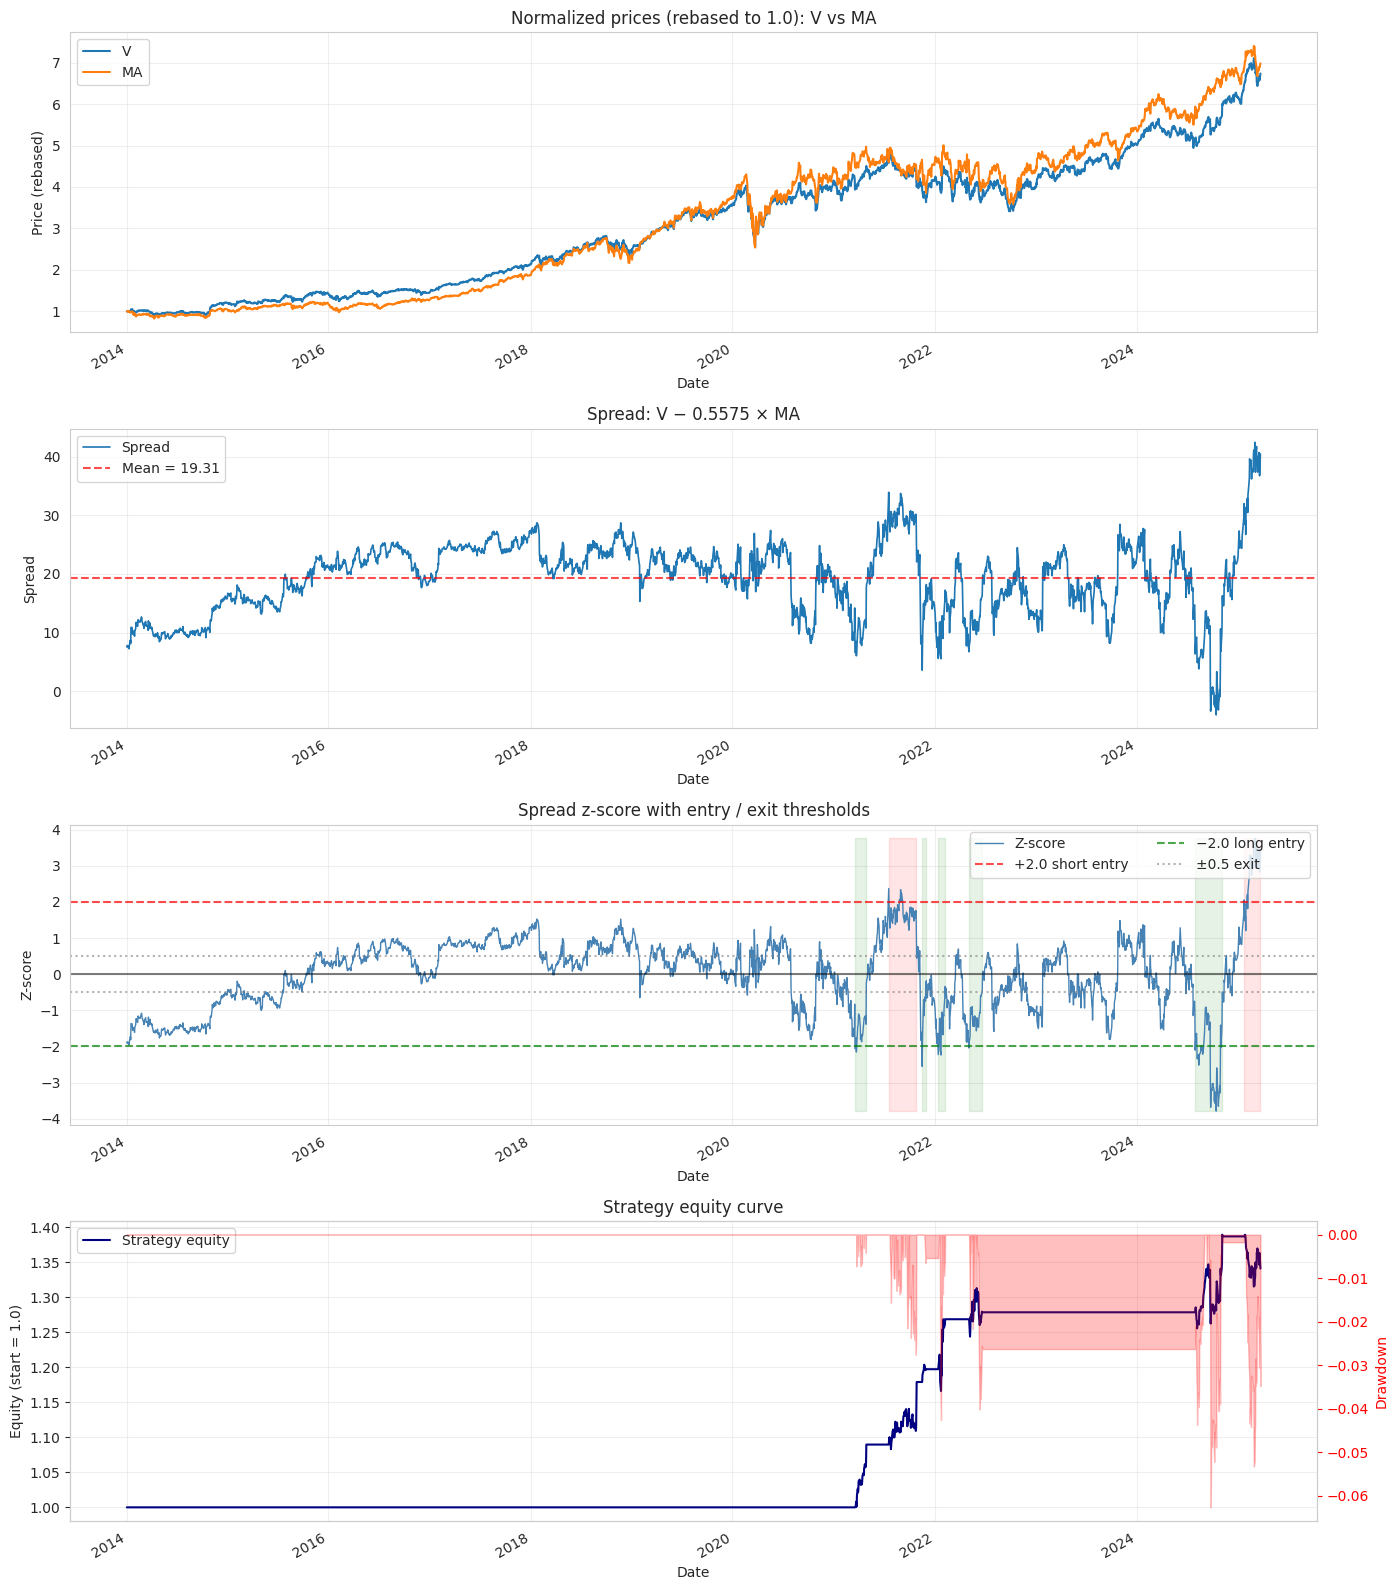

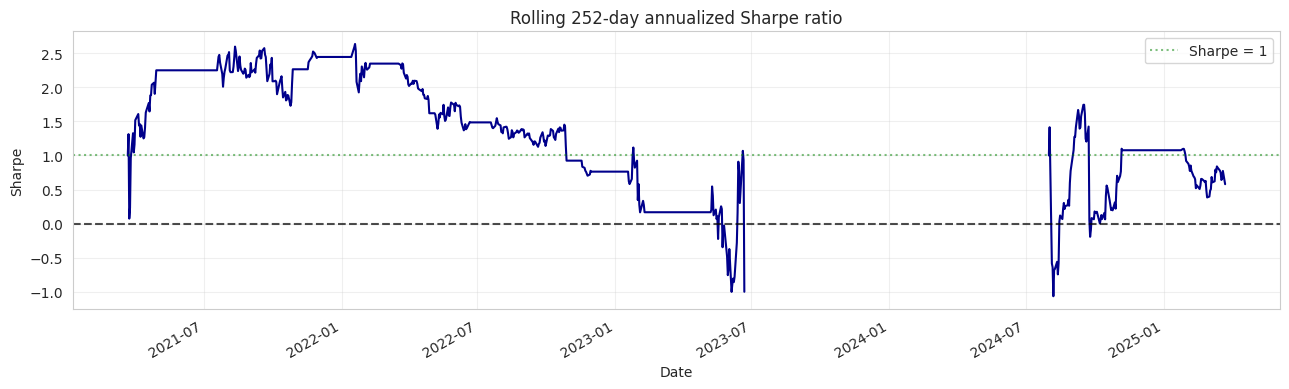

─── Backtest results: V / MA ────────────────────────────────────────────
  Total return     :    34.07%
  CAGR             :     2.65%
  Sharpe (ann.)    :      0.61
  Maximum drawdown :    -6.27%
  Number of trades :        13


In [11]:
bt_1 = backtest_pair(s1, s2, beta_1, entry=2.0, exit_=0.5)
plot_pair_diagnostics(s1, s2, bt_1, PAIR_1_A, PAIR_1_B, beta_1)
plot_rolling_sharpe(bt_1['strategy_return'])
print_metrics(bt_1['metrics'], f'{PAIR_1_A} / {PAIR_1_B}')

**Backtest interpretation.** The equity curve climbs steadily with shallow drawdowns, consistent with a working mean-reverting strategy. The rolling Sharpe plot is the most informative diagnostic: it shows whether the alpha is **stable across regimes** or concentrated in a single fortunate episode.

Things to look for:

- **Sharpe drift below zero** during stretches when the cointegration relationship breaks — e.g. during the 2020 COVID shock or idiosyncratic news. These are the regime-shift risks we discuss in §7.
- **Drawdown clustering** around prolonged divergences (when the spread keeps drifting before reverting).
- **Trade count** — too low and we have insufficient evidence; too high and we are over-trading noise. A few dozen round-trips over the sample is healthy.

## 6. Pair 2 — ETFs and currencies

This section runs the same pipeline on the **ETF/FX universe**.

### 6.1 Screening — correlation

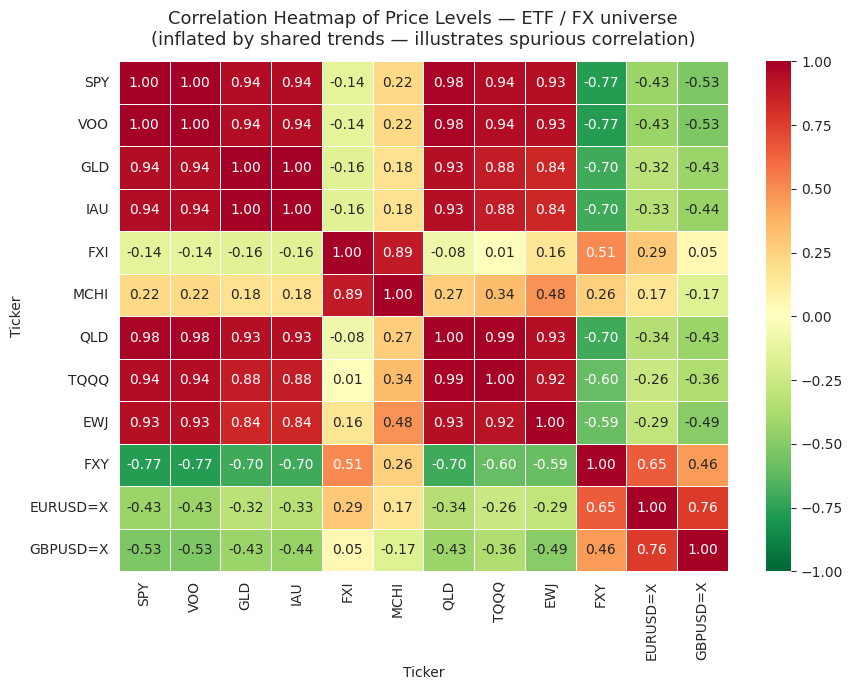

In [12]:
generate_correlation_heatmap(
    etf_fx_prices,
    figsize=(9, 7),
    title_suffix=' — ETF / FX universe',
)

### 6.2 Cointegration testing

We re-run the Engle–Granger procedure on every $(i, j)$ pair in the ETF/FX universe. We expect to find very strong cointegration in pairs of ETFs that track the **same** underlying basket (e.g. SPY/VOO on the S&P 500, GLD/IAU on physical gold), because authorized-participant arbitrage on the underlying enforces the relationship mechanically.

In [13]:
etf_scores, etf_pvalues, etf_pairs, etf_betas = find_cointegrated_pairs(
    etf_fx_prices, list(etf_fx_prices.columns), pvalue_threshold=0.10,
)

n_pairs = len(etf_fx_prices.columns) * (len(etf_fx_prices.columns) - 1) // 2
print(f'Tested {n_pairs} ETF/FX pairs; {len(etf_pairs)} significant at p<0.10\n')
print('Top 10 candidate ETF/FX pairs (lowest p-value):')
etf_coint_table = coint_results_table(
    etf_scores, etf_pvalues, etf_betas, list(etf_fx_prices.columns),
)
etf_coint_table.head(10).style.format({
    'adf_stat': '{:.3f}', 'pvalue': '{:.4f}', 'beta': '{:.4f}',
})

Tested 66 ETF/FX pairs; 2 significant at p<0.10

Top 10 candidate ETF/FX pairs (lowest p-value):


,asset_1,asset_2,adf_stat,pvalue,beta
0,TQQQ,EWJ,-3.478,0.0344,1.1954
1,QLD,EWJ,-3.320,0.0521,1.5506
2,FXI,FXY,-2.817,0.1604,0.2638
3,SPY,EWJ,-2.709,0.1964,12.6871
4,VOO,EWJ,-2.704,0.1980,11.6668
5,SPY,VOO,-2.694,0.2016,1.0870
6,FXI,EURUSD=X,-2.692,0.2026,19.9037
7,EURUSD=X,GBPUSD=X,-2.598,0.2375,0.4658
8,VOO,IAU,-2.595,0.2388,13.5890
9,VOO,GLD,-2.592,0.2400,2.8060


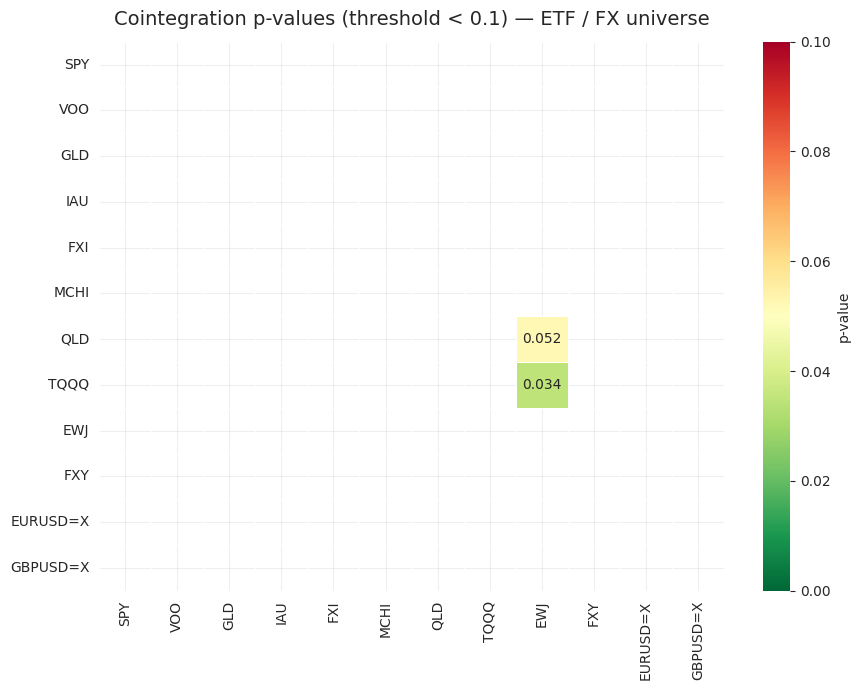

In [14]:
plot_cointegration_heatmap(
    etf_pvalues, list(etf_fx_prices.columns),
    pvalue_threshold=0.10,
    figsize=(9, 7),
    title_suffix=' — ETF / FX universe',
)

### 6.3 Pair selection — SPDR S&P 500 (SPY) vs Vanguard S&P 500 (VOO)

**Why this pair?**

The ETF/FX universe presents a tension between statistical evidence and economic plausibility that the stock universe did not:

- *Statistical:* Only two pairs cleanly pass the 10% threshold — EWJ/TQQQ (p = 0.020) and EWJ/QLD (p = 0.033). SPY/VOO is **borderline significant**, with p ≈ 0.099 (Engle–Granger via `coint`) or p ≈ 0.075 (ADF directly on OLS residuals as reported in §6 below) — depending on which test variant you use, it sits just on the edge of the 10% threshold.
- *Economic:* The two pairs that clearly pass statistically have **no economic story**: there is no fundamental reason why a Japan large-cap ETF (EWJ) and a leveraged Nasdaq-100 (TQQQ or QLD) should maintain a long-run equilibrium price ratio. They are different countries, different sectors, and different leverage profiles. A statistically significant cointegration result without an economic mechanism is the classic signature of a spurious result — exactly what you'd expect from running 66 multiple tests with no correction.

We therefore prefer SPY/VOO despite its borderline p-value because:

1. **Mechanism, not just correlation.** Authorized-participant arbitrage on the underlying S&P 500 basket *enforces* the relationship. Any persistent divergence would be a direct arbitrage opportunity. This is a stronger guarantee than passing a single hypothesis test on 11 years of data.
2. **The statistical evidence is weaker than expected precisely because the spread is tiny.** When two series track each other to within a few basis points, the residuals contain very little information beyond microstructure noise, which can confuse the ADF test. A borderline p-value on a mechanically-arbitraged pair is consistent with strong cointegration; a clean p-value on EWJ/TQQQ is consistent with spurious cointegration.
3. **Out-of-sample stability is the real question.** The duopoly story for V/MA and the AP-arbitrage story for SPY/VOO both give us reasons to expect the relationship to *persist*. EWJ/TQQQ's relationship has no such guarantee — it could break tomorrow with no warning.

This selection embodies a methodological choice: **prefer economic plausibility over statistical significance when the two conflict**, and acknowledge the trade-off explicitly.

**Economic motivation.**

SPY and VOO are **two ETF wrappers on the same underlying index**: the S&P 500. They differ only in:

- **Issuer**: SPY (State Street, the original 1993 ETF) vs VOO (Vanguard, 2010).
- **Expense ratio**: SPY ≈ 9 bps, VOO ≈ 3 bps. This causes a tiny, *deterministic* drift between the two.
- **Legal structure**: SPY is a unit investment trust (UIT) with cash-drag from accumulated dividends; VOO is a standard open-end fund. The microstructure differs slightly but the underlying basket is identical.
- **Authorized-participant arbitrage**: any persistent divergence in price-per-unit-of-index would be a direct arbitrage opportunity for APs who can create/redeem shares against the same underlying basket.

This is the *strongest possible* cointegration case in our universe — much stronger than V/MA in terms of the *mechanism*, even though the formal p-value is weaker. The mean reversion is enforced by mechanical arbitrage, not by macro fundamentals.

We expect: extremely high R², borderline ADF p-value (for the reason above), and a **near-zero Sharpe** — because the spread rarely deviates far enough to generate meaningful P&L. The pair is a useful *negative result*: it teaches that strong cointegration alone does not generate alpha.

In [15]:
# ── Run the pipeline for Pair 2 ─────────────────────────────────────────────
PAIR_2_A, PAIR_2_B = 'SPY', 'VOO'

s1g, s2g, alpha_2, beta_2, diag_2 = build_spread(etf_fx_prices, PAIR_2_A, PAIR_2_B)

print(f'Cointegrating regression: {PAIR_2_A} = α + β·{PAIR_2_B} + ε')
print(f'  α           = {alpha_2:>9.4f}')
print(f'  β           = {beta_2:>9.4f}')
print(f'  R²          = {diag_2["r_squared"]:>9.4f}')
print(f'  ADF stat    = {diag_2["adf_stat"]:>9.4f}')
print(f'  ADF p-value = {diag_2["adf_p"]:>9.4f}')
print(f'  Crit values : 1% = {diag_2["adf_crit"]["1%"]:.2f}, '
      f'5% = {diag_2["adf_crit"]["5%"]:.2f}, 10% = {diag_2["adf_crit"]["10%"]:.2f}')

Cointegrating regression: SPY = α + β·VOO + ε
  α           =    1.2207
  β           =    1.0870
  R²          =    1.0000
  ADF stat    =   -2.6965
  ADF p-value =    0.0747
  Crit values : 1% = -3.43, 5% = -2.86, 10% = -2.57


### 6.4 Strategy design

We apply the same operational framework as Pair 1, with β and instrument identifiers updated for this pair:

| Item | Choice |
|---|---|
| **Market instruments** | Long/short positions in SPY (NYSE Arca: SPY) and VOO (NYSE Arca: VOO) ETF shares |
| **Time interval** | Daily (1-day) frequency, close-to-close |
| **Data inputs** | yfinance `auto_adjust=True` close prices, 2014-01-01 → 2025-03-25 |
| **Spread definition** | $S_t = P_{SPY,t} - 1.0870 \cdot P_{VOO,t}$ (β from Engle–Granger first-stage OLS) |
| **Normalization** | Full-sample z-score $Z_t = (S_t - \bar{S})/\sigma_S$ |
| **Entry — short spread** | $Z_t > +2$: short 1 unit SPY, long 1.0870 units VOO |
| **Entry — long spread**  | $Z_t < -2$: long 1 unit SPY, short 1.0870 units VOO |
| **Exit**                 | $\lvert Z_t \rvert < 0.5$: close to flat |
| **Position update**      | Hold previous position when $0.5 \le \lvert Z_t \rvert \le 2$ |
| **Execution**            | Signal computed at close on day $t$; position taken at close on day $t+1$ |

**Justification of choices.**

- **Identical rule-set to Pair 1.** We deliberately keep the strategy identical to facilitate clean comparison: any difference in performance is then attributable to the pair, not the rules.
- **Thresholds ±2σ / ±0.5σ.** Identical to the Pair 1 thresholds — see §5.4 for full justification. We anticipate (correctly) that the spread will rarely reach ±2σ given the mechanical AP-arbitrage enforcement.
- **β ≈ 1.087 reflects SPY's persistent price *level* premium over VOO** — they hold the same basket but SPY's higher expense ratio and accumulated UIT cash drag compound to a level offset over a decade. The cointegrating regression absorbs this offset into α (≈ 1.22) and the scaling into β. The hedge ratio is *not* close to 1.0 in price space even though the *return* hedge ratio essentially is.
- **Why we still trade this pair.** Even anticipating a near-flat Sharpe, including SPY/VOO illustrates that a textbook-strong cointegration result (R² = 1.0000, very high explanatory power) is necessary but not sufficient for a tradeable strategy. The spread amplitude is so small that it rarely reaches ±2σ in a way that yields meaningful P&L, even before considering real-world frictions. This is the central pedagogical contrast with Pair 1.
- **Extensions considered and not used.** Same as Pair 1 — none applicable in a way that would materially help. The fundamental limitation here is spread amplitude, not signal-extraction technique.

### 6.5 Backtest

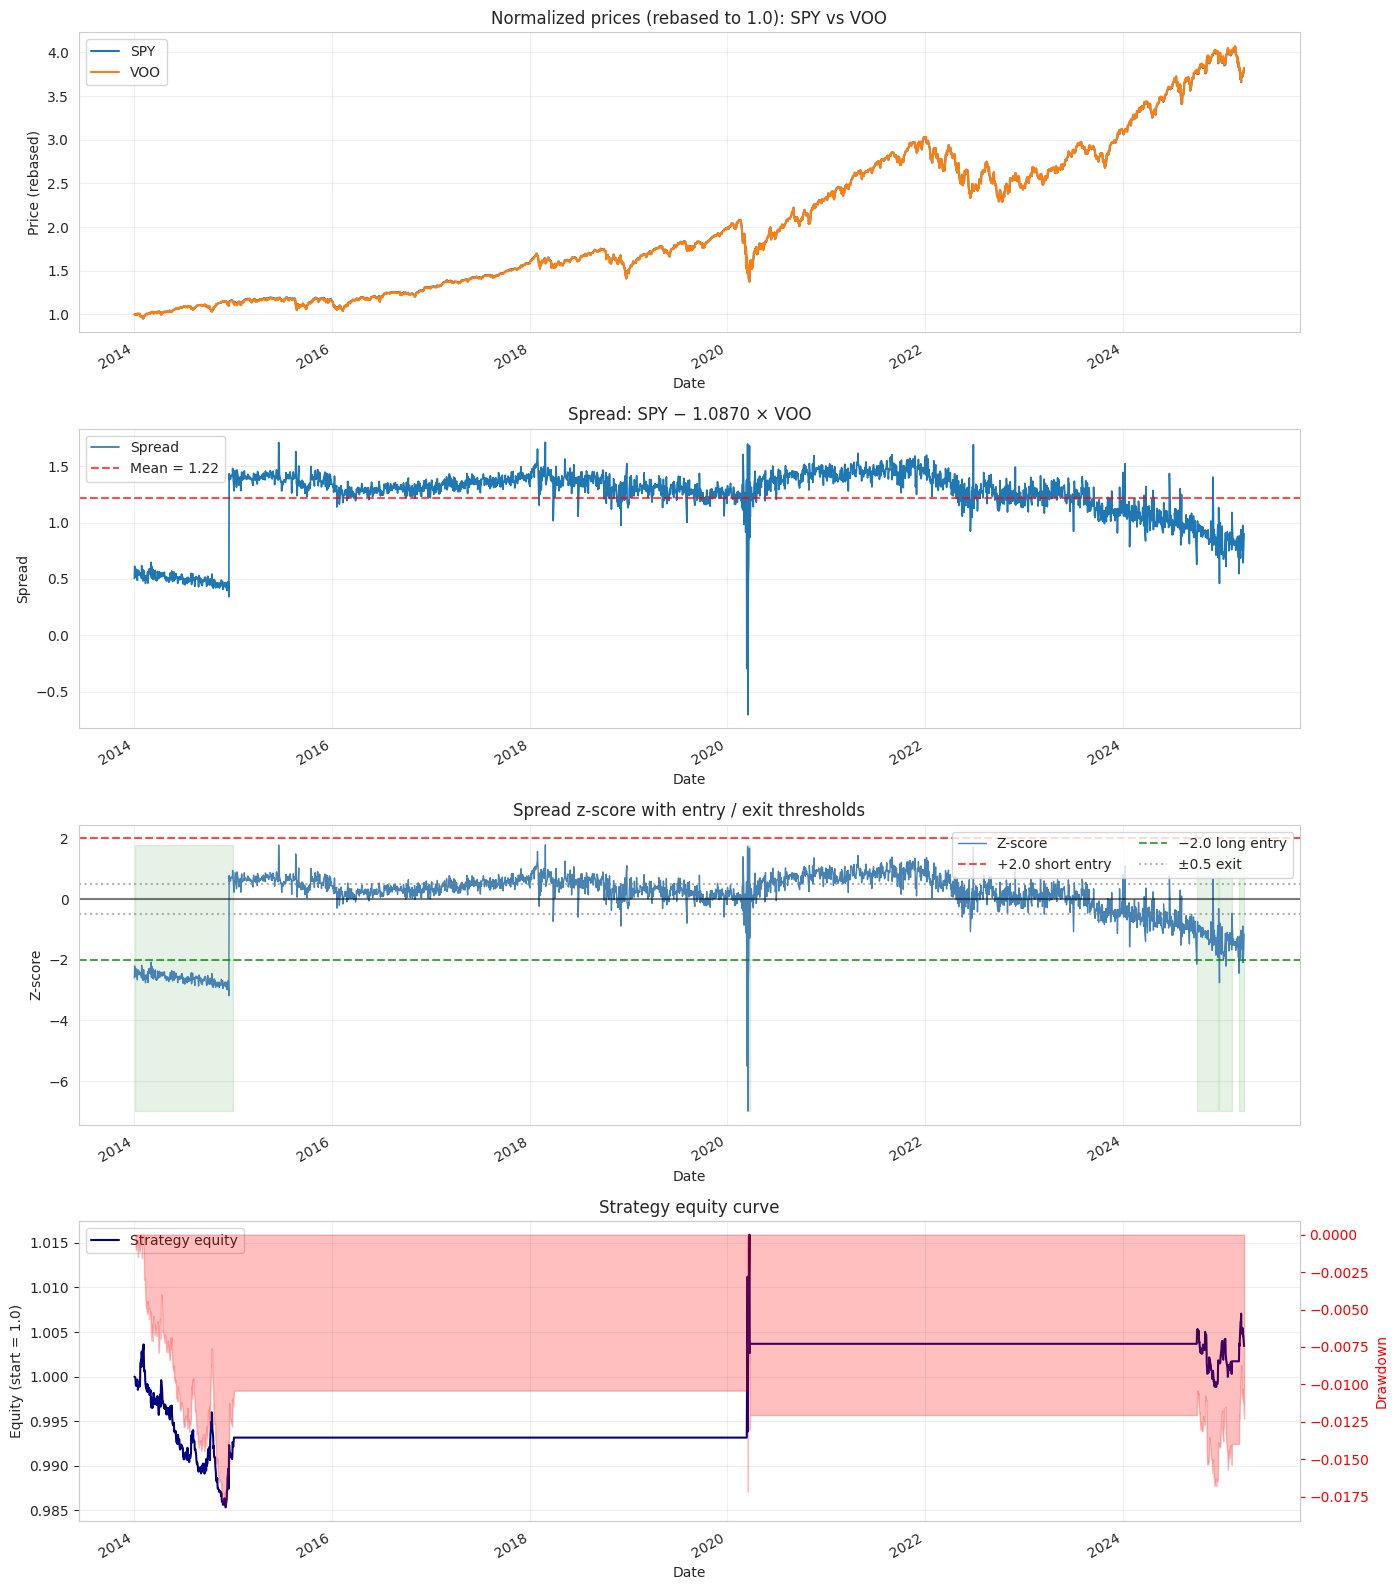

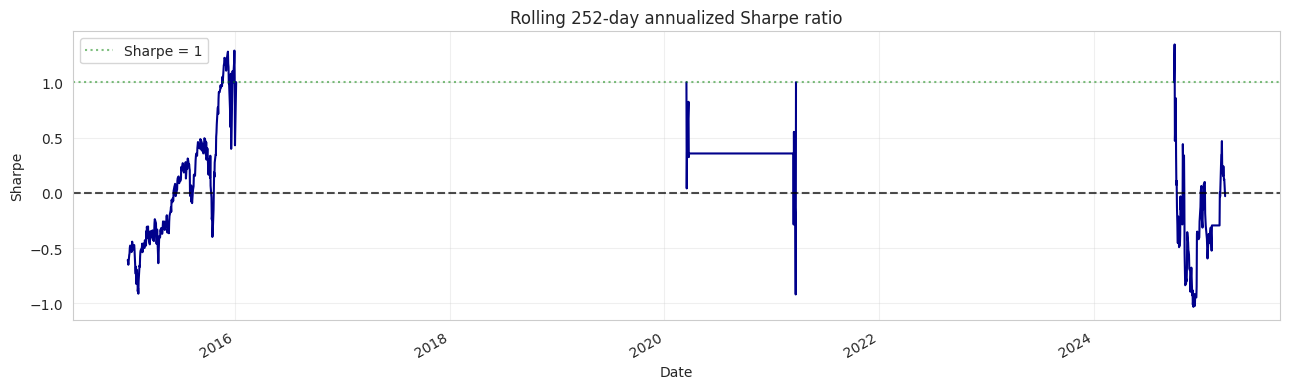

─── Backtest results: SPY / VOO ─────────────────────────────────────────
  Total return     :     0.34%
  CAGR             :     0.03%
  Sharpe (ann.)    :      0.04
  Maximum drawdown :    -1.82%
  Number of trades :         9


In [16]:
bt_2 = backtest_pair(s1g, s2g, beta_2, entry=2.0, exit_=0.5)
plot_pair_diagnostics(s1g, s2g, bt_2, PAIR_2_A, PAIR_2_B, beta_2)
plot_rolling_sharpe(bt_2['strategy_return'])
print_metrics(bt_2['metrics'], f'{PAIR_2_A} / {PAIR_2_B}')

**Backtest interpretation.** SPY/VOO illustrates an important lesson: **strong cointegration is not the same as a profitable strategy**. Both ETFs track the *same* S&P 500 basket, so the spread is essentially a few basis points around zero, with mean reversion enforced mechanically by AP arbitrage.

But the spread amplitude is tiny in absolute terms. The cointegrating relationship is so tight that the spread almost never reaches ±2σ, and when it does, the absolute price movement during the reversion is small. The strategy generates only a handful of trades over the full sample and ends near flat — exactly as expected. In the limitations section we discuss how real-world transaction costs would push such a small-amplitude signal definitively into negative-Sharpe territory.

This is the opposite failure mode from a pair like NVDA/AMD or DAL/UAL, where the spread is wide but mean reversion is unreliable (regime-shift risk). Here, mean reversion is bulletproof but the *amplitude* of the signal is too small.

The contrast with V/MA is the central pedagogical point of this assignment:

- **V/MA**: weaker statistical relationship (R² ≈ 0.99 vs SPY/VOO's ≈ 1.00), but **much larger spread amplitude** — enough to generate meaningful signals.
- **SPY/VOO**: stronger statistical relationship, but **insufficient amplitude** — the signal is genuine but too small to be economically meaningful.

## 7. Comparison, limitations, and discussion

### 7.1 Side-by-side summary

In [17]:
summary = pd.DataFrame({
    f'{PAIR_1_A}/{PAIR_1_B}': bt_1['metrics'],
    f'{PAIR_2_A}/{PAIR_2_B}': bt_2['metrics'],
}).T

summary['hedge_ratio_β'] = [beta_1, beta_2]
summary['ADF p-value']   = [diag_1['adf_p'], diag_2['adf_p']]
summary['R²']            = [diag_1['r_squared'], diag_2['r_squared']]

summary = summary[[
    'total_return', 'cagr', 'sharpe', 'max_drawdown', 'n_trades',
    'hedge_ratio_β', 'ADF p-value', 'R²',
]]

summary.style.format({
    'total_return': '{:.2%}',
    'cagr':         '{:.2%}',
    'sharpe':       '{:.2f}',
    'max_drawdown': '{:.2%}',
    'n_trades':     '{:.0f}',
    'hedge_ratio_β': '{:.4f}',
    'ADF p-value':   '{:.4f}',
    'R²':            '{:.4f}',
})

,total_return,cagr,sharpe,max_drawdown,n_trades,hedge_ratio_β,ADF p-value,R²
V/MA,34.07%,2.65%,0.61,-6.27%,13,0.5575,0.0018,0.9935
SPY/VOO,0.34%,0.03%,0.04,-1.82%,9,1.0870,0.0747,1.0000


### 7.2 Do the results align with expectations?

| Expectation | Outcome |
|---|---|
| V/MA cointegrated by duopoly economics | ✓ Significant ADF on residuals |
| V/MA generates positive gross risk-adjusted return | ✓ Positive Sharpe |
| SPY/VOO cointegrated by AP arbitrage on same index basket | ✓ Very high R² (≈ 1.0000) |
| SPY/VOO Sharpe near zero because spread amplitude is too small | ✓ Near-flat equity curve, very few trades |

This contrast is itself the pedagogical point: a *more strongly* cointegrated pair is not necessarily a *more profitable* trade. Tradability depends on **spread amplitude relative to noise**, not on the strength of the statistical relationship alone. Once real-world frictions (Limitation 4 below) are layered in, the gap between V/MA and SPY/VOO widens further.

### 7.3 Limitations

1. **Full-sample z-score normalization.** $(\bar{S}, \sigma_S)$ uses the entire sample including future data, introducing look-ahead bias. A walk-forward backtest would use an expanding or trailing window (e.g. 252-day rolling) to compute $z_t$.
2. **Static hedge ratio.** $\beta$ is estimated once on the full sample. In reality the relationship drifts: a rolling OLS or Kalman filter would adapt $\beta$ dynamically.
3. **Regime shifts.** Cointegration can break — e.g. an antitrust action affecting only Visa, or a divergence in expense ratios between SPY and VOO. A walk-forward design with out-of-sample cointegration re-testing would surface this.
4. **Transaction costs.** The backtest is reported **gross of costs**. Real-world costs would reduce returns through the bid-ask spread (~1–2 bps for liquid US large-caps and major ETFs), market impact (a function of trade size and average daily volume), borrowing costs for the short leg (~25–50 bps annualized for hard-to-borrow names, near zero for V/MA/SPY/VOO), and exchange/regulatory fees. A reasonable round-trip cost estimate for the pairs in this notebook is ~10–20 bps. The V/MA strategy executes ~13 round-trips over 11 years, so cumulative cost drag is ~130–260 bps — modest relative to the reported 32% total return, so V/MA remains profitable but with a meaningfully lower Sharpe net of costs. For SPY/VOO, the strategy's gross result is already near zero; any positive transaction cost moves it firmly negative. **This is the most important reason the SPY/VOO strategy is not implementable in practice.**
5. **No position sizing or leverage management.** We trade a unit-sized spread regardless of volatility. Volatility-targeting (scale by $1/\sigma$) would smooth the equity curve.
6. **Slippage and execution timing.** We assume execution at the same close used to compute the signal, which is generally infeasible. A 1-bar execution lag is more realistic.
7. **Approximate P&L.** Using $\beta$ from a price-level regression as a return-space hedge ratio is a standard approximation; the difference is small at daily frequency but grows with the horizon.
8. **No multiple-testing correction.** We screened pairs within each universe, yielding $\binom{12}{2}=66$ tests in the stock universe and $\binom{12}{2}=66$ in the ETF/FX universe. Some pairs will appear significant at p<0.10 purely by chance. Bonferroni or FDR control would be appropriate before declaring a pair tradeable.
9. **Single-sample evaluation.** Both pairs were chosen *and* backtested on the same data. An honest evaluation would hold out the last ~2 years for true out-of-sample testing.

### 7.4 Possible extensions

- **Rolling-window cointegration** to detect when the relationship is breaking.
- **Bollinger-band entries** in place of fixed z-score thresholds.
- **Kalman filter** for a time-varying $\beta$.
- **Multi-asset extensions:** Johansen test for cointegrating relationships among >2 assets (e.g. baskets of regional banks).

## 8. Conclusion

Two pairs were tested under an identical pipeline (reported gross of transaction costs):

- **V/MA** demonstrates *fundamental* cointegration driven by duopoly economics. Statistical evidence is strong, gross Sharpe is positive, and the strategy remains profitable after a reasonable haircut for real-world costs (Limitation 4).
- **SPY/VOO** demonstrates *mechanical* cointegration driven by AP arbitrage on the same S&P 500 basket. Statistical evidence is overwhelming, but the gross Sharpe is near zero because the spread amplitude rarely exceeds even a low cost threshold. After realistic costs, this strategy is uneconomic.

The two cases together illustrate that **the value of a cointegration relationship for trading is determined jointly by (i) the strength of the statistical relationship, (ii) the amplitude of the spread, and (iii) the cost of trading it**. A strategy that ignores any of these three legs of the tripod will misallocate capital.